# Congruent Types

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from tfds.plotting import prettify, use_tex

# use_tex()

In [12]:
def objective(x):
    obj = x * (gamma * (1 - theta_h) - (1 - theta_l) - (gamma - 1) * (tau - 3 * tau * prob_state0 + 2 * tau * (prob_state0 ** 2)))
    cost_h = tau * (1 - 2 * prob_state0 + 2 * (prob_state0 ** 2))
    obj += -gamma + gamma * theta_h + gamma * cost_h - (gamma - 1) * tau * prob_state0
    return obj

def func_of_x(x):
    return x * (gamma * (1 - theta_h) - (1 - theta_l) - (gamma - 1) * (tau - 3 * tau * prob_state0 + 2 * tau * (prob_state0 ** 2)))

def transfer_low(x):
    return (1 - theta_l) * x

def transfer_high(x):
    return x * (theta_h - theta_l) + 1 - theta_h

def cost_high(x):
    return tau * (1 - 2 * prob_state0 + 2 * (prob_state0 ** 2))

def cost_low(x):
    return tau * (prob_state0 + x - 3 * prob_state0 * x + 2 * x * (prob_state0 ** 2))

- I just needed these two expressions to match, yay!

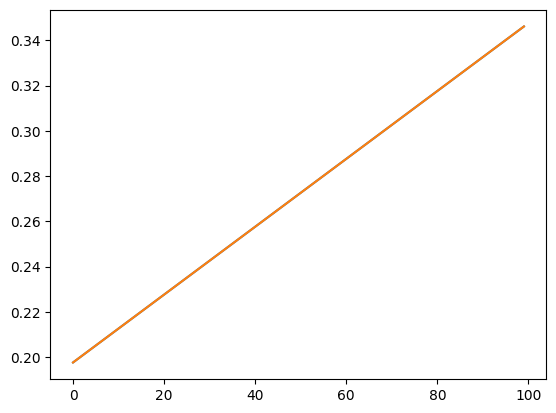

In [3]:
#N = 1000
tau = 1
theta_l = 0.75
theta_h = 0.5
gamma = 0.45
prob_state0 = 0.280808

N = 100
xs = np.linspace(0, 1, N)

obj = -(1 - gamma) * (transfer_low(xs)  - cost_low(xs)) - gamma * (transfer_high(xs)  - cost_high(xs))
plt.plot(obj)
plt.plot(objective(xs))

- Now we look at what happens to the optimal $x$ (full information or no information) when we vary prob_state0.

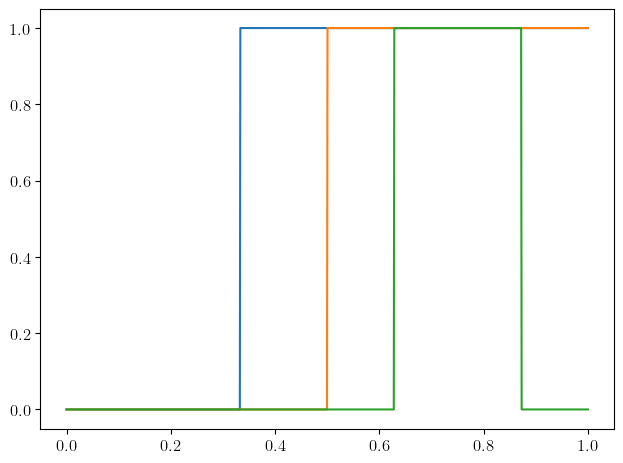

In [205]:
N = 1000
tau = 1
theta_l = 0.75
theta_h = 0.5
gamma = 0.3

N = 1000
xs = np.linspace(0, 1, N)
objectives = objective(xs)
prob_state0s = [0, 0.1, 0.2, 0.317, 0.4]
prob_state0s = np.linspace(0, 1, 1000)

# fig, ax = plt.subplots()
fig, ax = plt.subplots()
gammas = [0.1, 0.4999999, 0.58]

for gamma in gammas:

    directions = []
    diffs = []
    actions = []
    for prob_state0 in prob_state0s:
        objectives = func_of_x(xs)

        if objectives[0] <= objectives[-1]:
            action = 0
        else:
            action = 1
        actions.append(action)

 
    ax.plot(prob_state0s, actions)


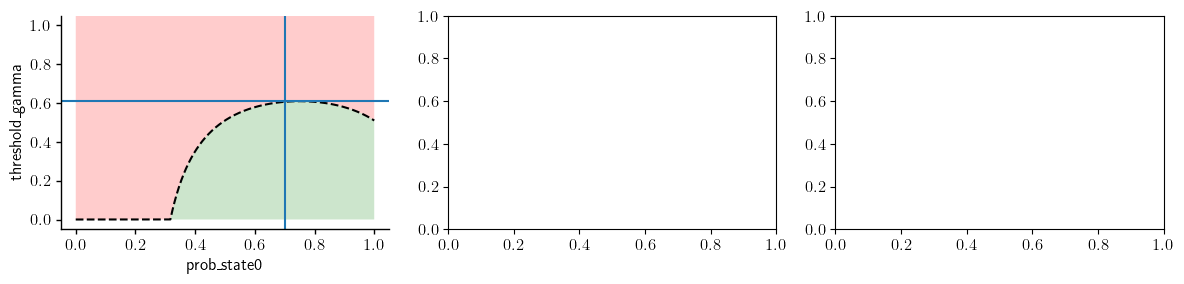

In [223]:
theta_h = 0.51
theta_l = 0.75

prob_state0s = np.linspace(0, 1, 10000)

fig, axs  = plt.subplots(1, 3, figsize=(12, 3 ))

import matplotlib as mpl

taus = [0, 1, 100]
taus = [1]


for i, tau in enumerate(taus):
    ax = axs[i]
    threshold_gammas = []
    for prob_state0 in prob_state0s:
        cost_term = tau - 3 * tau * prob_state0 + 2 * (prob_state0 ** 2) * tau        
        threshold_gamma = (1 - theta_l - cost_term) / (1 - theta_h - cost_term)
        threshold_gammas.append(threshold_gamma)




    threshold_gammas = np.array(threshold_gammas)


    threshold_gammas_2 = threshold_gammas.copy()
    threshold_gammas_2[(threshold_gammas < 0) | (threshold_gammas>1)] = 0
    # ax.plot(prob_state0s, threshold_gammas, ls="--", c="k")
    ax.plot(prob_state0s, threshold_gammas_2, ls="--", c="k")


    ax.set_xlabel("prob_state0")
    ax.set_ylabel("threshold_gamma")
    ax.set_xlim(left=-0.05, right=1.05)
    ax.set_ylim(top=1.05, bottom=-0.05)



    ax.fill_between(
        prob_state0s, 
        threshold_gammas_2,
        2, 
        facecolor="red", 
        alpha=.2)


    ax.fill_between(
        prob_state0s, 
        0,
        threshold_gammas_2,
        facecolor="green", 
        alpha=.2)

    ax.axvline(x=0.7)
    ax.axhline(y=0.61)


prettify(ax=ax)


(0.0, 2.0)

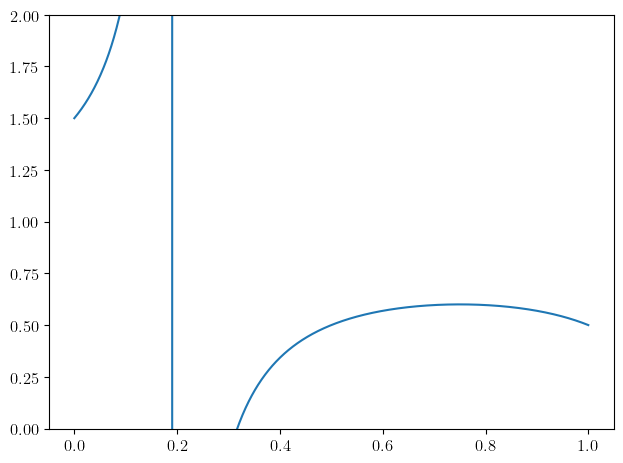

In [51]:
alphas = np.linspace(0, 1, 1000)
D = lambda alpha: (tau - 3 * alpha * tau + 2 * (alpha ** 2) * tau)

rhs = lambda alpha: (1 - theta_l - D(alphas)) / (1 - theta_h - D(alphas)) 
plt.plot(alphas, rhs(alphas))
plt.ylim(top=2, bottom=0)

In [119]:
1 - theta_h
tau = 1

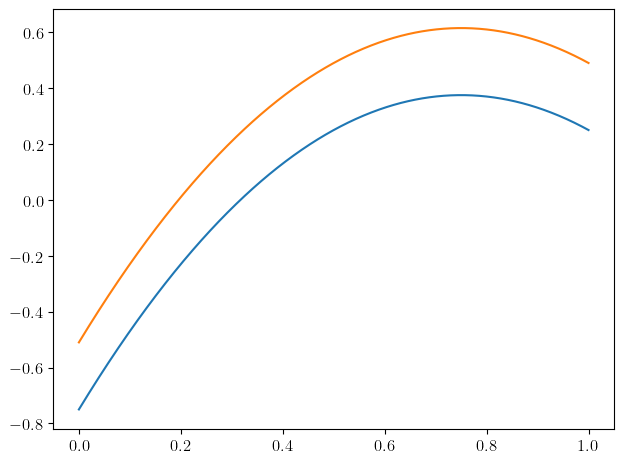

In [120]:
plt.plot(alphas, 1 - theta_l - D(alphas))
plt.plot(alphas, 1 - theta_h - D(alphas))

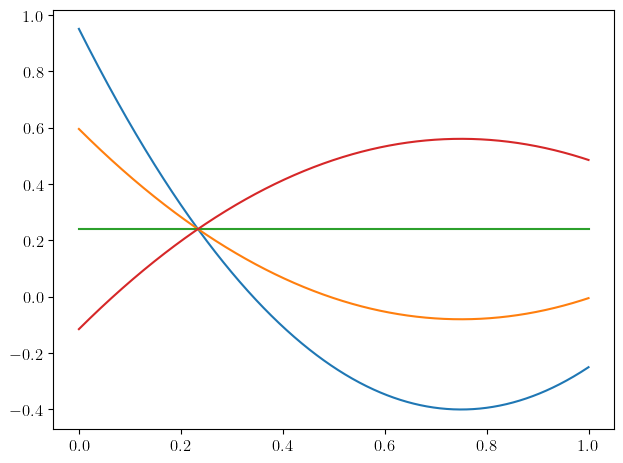

In [213]:
gammas = [0, 0.5, 1, 1.5] # Above gamma = 1. the objective is concanve so we swap..
tau = 1.2
for gamma in gammas:

    plt.plot(alphas, gamma * (1 - theta_h) - (1 - theta_l) - (gamma - 1) * D(alphas))

#  Notes below here

Text(0.5, 0, 'low type')

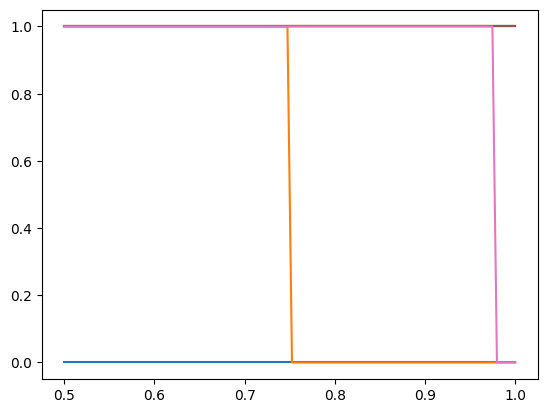

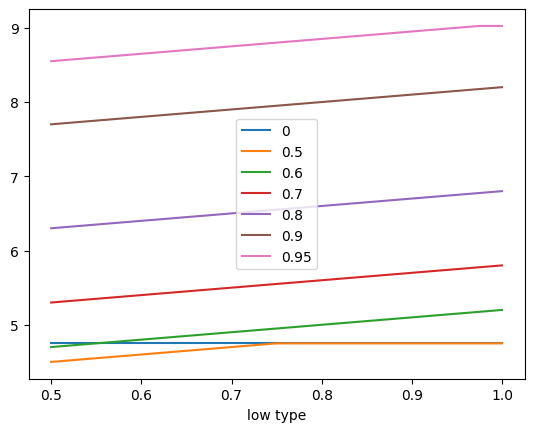

In [744]:
gamma = 0.5
theta_h = 0.5
tau = 10

def objective(vars):
    x, trans_h, trans_l = vars[0], vars[1], vars[2]
    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0)
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x) - (1 - x) * (1 - 2 * prob_state0)
    )

    return -gamma * (trans_l - cost_l) - (1-gamma) * (trans_h - cost_h)

def constraint1(vars):
    x, trans_h, trans_l = vars
    return (1 - theta_h) * (1 - x) - (trans_h - trans_l)


def constraint2(vars):
    x, trans_h, trans_l = vars
    return (1 - theta_l) * (x - 1) - (trans_l - trans_h)


def constraint3(vars):
    x, trans_h, trans_l = vars
    return (1 - theta_l) * x - trans_l

def constraint4(vars):
    x, trans_h, trans_l = vars
    return (1 - theta_h) - trans_h

bounds = [(0, 1)]

# Initial guess for the variables
x0 = [0, 0, 0]

constraints = [
        {'type': 'ineq', 'fun': constraint1},
        {'type': 'ineq', 'fun': constraint2},
        {'type': 'ineq', 'fun': constraint3},
        {'type': 'ineq', 'fun': constraint4},
    ]

constraints = [
        {'type': 'eq', 'fun': constraint1},
        #{'type': 'ineq', 'fun': constraint2},
        {'type': 'eq', 'fun': constraint3},
        #{'type': 'ineq', 'fun': constraint4},
    ]


from scipy.optimize import minimize

theta_ls = np.linspace(0.5, 1, 100)
prob_state0s = [0, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]


fig, ax = plt.subplots()
fig2, ax2 = plt.subplots()
for prob_state0 in prob_state0s:



    objectives = []
    results = []
    for theta_l in theta_ls:
        # Optimization using SLSQP method
        result = minimize(
            objective,
            x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            tol=1e-10,
            options={"maxiter":10000000}
        )
        results.append(result.x[0])
        objectives.append(result.fun)

    ax.plot(theta_ls, results)
    ax2.plot(theta_ls, objectives, label=prob_state0)
    #plt.axvline(x=0.75)
ax2.legend()
ax2.set_xlabel("low type")

In [726]:
theta_l = 0.75
theta_h = 0.5
tau = 1
prob_state0 = 0.3
x0 = np.random.uniform(size=3)
gamma = 0.5

constraints = [
        {'type': 'eq', 'fun': constraint1},
        #{'type': 'eq', 'fun': constraint2},
        {'type': 'eq', 'fun': constraint3},
        #{'type': 'eq', 'fun': constraint4},
    ]

constraints = [
        {'type': 'ineq', 'fun': constraint1},
        {'type': 'ineq', 'fun': constraint2},
        {'type': 'ineq', 'fun': constraint3},
        {'type': 'ineq', 'fun': constraint4},
    ]


result = minimize(
            objective,
            x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            tol=1e-10,
            options={"maxiter":10000000}
        )

In [727]:
result.x

array([3.74700271e-16, 5.00000000e-01, 5.34294831e-16])

In [728]:
result.fun

0.18999999999999934

In [102]:
def externality(q):
    return tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * q + (1 - 2*prob_state0) * np.minimum(-q, 0))

In [101]:
tau = 0.2
prob_state0 = 0.002
externality(-1)

-0.0

In [103]:
tau * (1 - 2 * prob_state0)

-1.6

In [104]:
tau * prob_state0

1.8

In [106]:
1 - 2 * prob_state0

-0.8

In [284]:
gamma = 0.6
theta_h = 0.5
theta_l = 0.75
tau = 10
prob_state0 = 1

def objective(vars):
    x_l, x_h, trans_h, trans_l = vars
    cost_h = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_h) - (1 - x_h) * (1 - 2 * prob_state0))
    cost_l = tau * prob_state0 + tau * (1 - 2 * prob_state0) * (1 - prob_state0 - prob_state0 * (1 - x_l) - (1 - x_l) * (1 - 2 * prob_state0))
    return -gamma * (trans_l - cost_l) - (1-gamma) * (trans_h - cost_h)

def constraint1(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_h) * (x_h - x_l) - (trans_h - trans_l)


def constraint2(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_l) * (x_l - x_h) - (trans_l - trans_h)


def constraint3(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_l) * x_l - trans_l

def constraint4(vars):
    x_l, x_h, trans_h, trans_l = vars
    return (1 - theta_h) * x_h - trans_h

bounds = [(0, 1), (0, 1), (0, None), (0, None)]

# Initial guess for the variables
x0 = np.random.uniform(size=4)

constraints = [
        {'type': 'ineq', 'fun': constraint1},
        {'type': 'ineq', 'fun': constraint2},
        {'type': 'ineq', 'fun': constraint3},
        {'type': 'ineq', 'fun': constraint4},
    ]

# constraints = [
#         {'type': 'eq', 'fun': constraint1},
#         #{'type': 'ineq', 'fun': constraint2},
#         {'type': 'eq', 'fun': constraint3},
#         #{'type': 'ineq', 'fun': constraint4},
#     ]


from scipy.optimize import minimize
result = minimize(
            objective,
            x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            tol=1e-10,
            options={"maxiter":10000000}
        )

result.x

array([1.  , 1.  , 0.25, 0.25])

In [267]:
prob_state0

1.0